# Inheritance

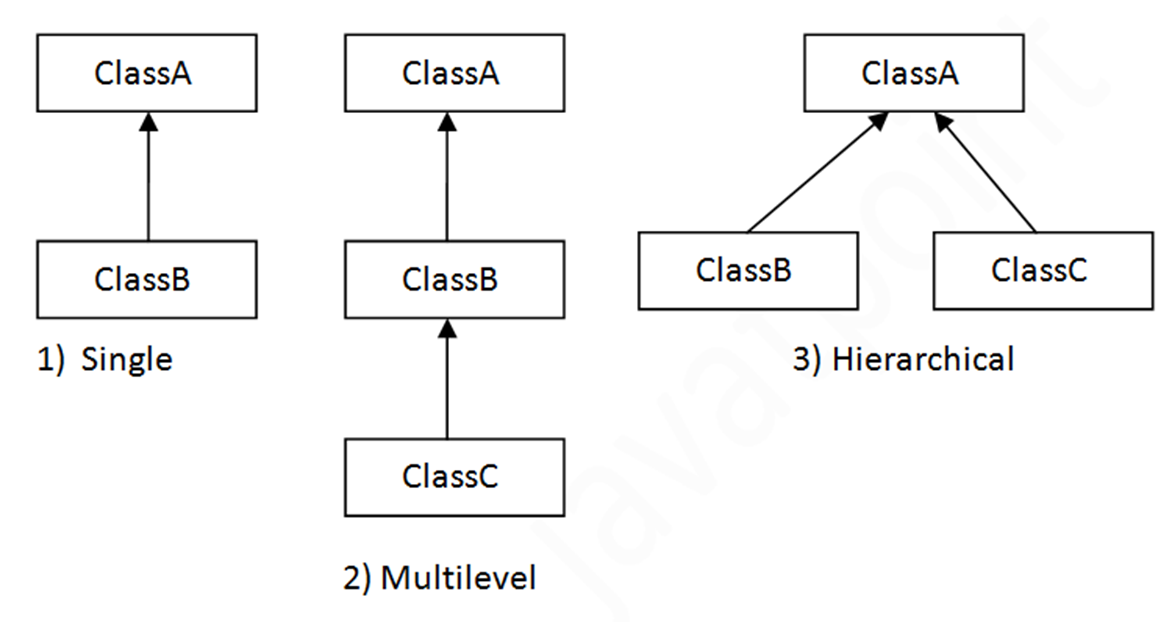

# 1. Single Inheritance
1. One Parent class one child class
2. Child class inherits attributes and methods of parent class

In [7]:
class Person:

    def __init__(self, name: str, age: int):
        self.name = name
        self.age = age

    def intro(self):
        print(f"My name is {self.name}")
        print(f"I am {self.age} years old")

In [8]:
class Employee(Person):

    def __init__(self, name: str, age: int, company: str):
        super().__init__(name, age)
        self.company = company

    def work(self):
        print(f"I work at {self.company}")

In [9]:
p1 = Person(name="Rahul", age=28)
print(type(p1))

<class '__main__.Person'>


In [10]:
p1.name

'Rahul'

In [11]:
p1.age

28

In [12]:
p1.intro()

My name is Rahul
I am 28 years old


In [13]:
e1 = Employee(name="Aditi", age=32, company="TCS")
print(type(e1))

<class '__main__.Employee'>


In [15]:
e1.name

'Aditi'

In [16]:
e1.age

32

In [17]:
e1.company

'TCS'

In [18]:
e1.work()

I work at TCS


In [19]:
# Intro method got inherited from Parent class person
e1.intro()

My name is Aditi
I am 32 years old


In [20]:
e1.intro()
e1.work()

My name is Aditi
I am 32 years old
I work at TCS


# Practical application
pydantic module in python can be used for data validation

In [21]:
!uv add pydantic

Resolved 137 packages in 188ms
Audited 132 packages in 1ms


# Conditons in pydantic
1. ge - greater than or equal to
2. le - less than or equal to
4. gt - greater than
5. lt - less than

In [23]:
# Base model in pydantic is responsible for validating data
# Field is used to add some checks to data
from pydantic import BaseModel, Field
from typing import Literal

In [24]:
class Student(BaseModel):
    roll_no: int = Field(ge=101, le=1000)
    name: str = Field(max_length=20)
    age: int = Field(ge=18, le=100)
    marks: float = Field(ge=0.0, le=100.0)
    gender: Literal["male", "female"]
    hobbies: list[str] = Field(default_factory=list)

    def get_student_info(self):
        print(f"Roll Number : {self.roll_no}")
        print(f"Name : {self.name}")
        print(f"Marks : {self.marks}")
        print(f"Gender : {self.gender}")
        print(f"Hobbies : {self.hobbies}")

In [26]:
s1 = Student(
    roll_no=101,
    name="Raman",
    age=25,
    marks=85.3,
    gender="male",
    hobbies=["cricket", "singing"],
)

In [27]:
s1.roll_no

101

In [28]:
s1.name

'Raman'

In [29]:
s1.age

25

In [30]:
s1.marks

85.3

In [31]:
s1.gender

'male'

In [32]:
s1.hobbies

['cricket', 'singing']

In [33]:
s1.get_student_info()

Roll Number : 101
Name : Raman
Marks : 85.3
Gender : male
Hobbies : ['cricket', 'singing']


In [35]:
s1

Student(roll_no=101, name='Raman', age=25, marks=85.3, gender='male', hobbies=['cricket', 'singing'])

In [34]:
print(s1)

roll_no=101 name='Raman' age=25 marks=85.3 gender='male' hobbies=['cricket', 'singing']


In [37]:
s1.model_dump()

{'roll_no': 101,
 'name': 'Raman',
 'age': 25,
 'marks': 85.3,
 'gender': 'male',
 'hobbies': ['cricket', 'singing']}

In [39]:
s2 = Student(roll_no=105.2, name=12, age=200, marks=-5.3, hobbies="singing", gender="M")

ValidationError: 6 validation errors for Student
roll_no
  Input should be a valid integer, got a number with a fractional part [type=int_from_float, input_value=105.2, input_type=float]
    For further information visit https://errors.pydantic.dev/2.11/v/int_from_float
name
  Input should be a valid string [type=string_type, input_value=12, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/string_type
age
  Input should be less than or equal to 100 [type=less_than_equal, input_value=200, input_type=int]
    For further information visit https://errors.pydantic.dev/2.11/v/less_than_equal
marks
  Input should be greater than or equal to 0 [type=greater_than_equal, input_value=-5.3, input_type=float]
    For further information visit https://errors.pydantic.dev/2.11/v/greater_than_equal
gender
  Input should be 'male' or 'female' [type=literal_error, input_value='M', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/li

In [42]:
s3 = Student(
    roll_no=102,
    name="Priya",
    age=33,
    marks=67.5,
    gender="female",
)

In [43]:
s3

Student(roll_no=102, name='Priya', age=33, marks=67.5, gender='female', hobbies=[])

In [44]:
s3.get_student_info()

Roll Number : 102
Name : Priya
Marks : 67.5
Gender : female
Hobbies : []


In [ ]:
# model dump function is inherited from BaseModel
s3.model_dump()

{'roll_no': 102,
 'name': 'Priya',
 'age': 33,
 'marks': 67.5,
 'gender': 'female',
 'hobbies': []}